In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from natsort import natsorted
from scipy import stats

In [5]:
# Loading files efficiently

FOLDER_PATH = '/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks'
file_paths = natsorted(Path(FOLDER_PATH).glob("*.npy"))
print(file_paths)
grand_trajectories_list = []
grand_height = np.zeros(len(file_paths))
grand_width = np.zeros(len(file_paths))

for i,file in enumerate(file_paths):
    data = np.load(file, allow_pickle=True)
    value = data.item()
    traj = value['trajectories']
    height = value['height']
    width = value['width']
    grand_trajectories_list.append(traj)
    grand_height[i] = height
    grand_width[i] = width

grand_trajectories_array = np.stack(grand_trajectories_list, axis=0)

colors_ind = ['#17707B', '#70A551', '#F9B859', '#80173A']
colors_MD = ['#ED2027', '#63B9CA', '#2166B1']
colors_phase =['#FFD045', "#8E1C3B", '#56C0BC']

[PosixPath('/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks/trial_1_trajectories.npy'), PosixPath('/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks/trial_2_trajectories.npy'), PosixPath('/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks/trial_3_trajectories.npy'), PosixPath('/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks/trial_4_trajectories.npy'), PosixPath('/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks/trial_6_trajectories.npy'), PosixPath('/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks/trial_7_trajectories.npy'), PosixPath('/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks/trial_8_trajectories.npy'), PosixPath('/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/tracked/1c_3n/tracks/trial_9_trajectories.npy'),

In [6]:
# rescaling - pixels to cm
tank_dimensions = (50, 20, 20)
trialwise_conv_factor = np.array([tank_dimensions[0]/grand_width[i] for i in range(len(file_paths))])
grand_trajectories_array *= trialwise_conv_factor[:, np.newaxis, np.newaxis, np.newaxis]

In [7]:
# normalised time axes

light_on_frame_list = np.array([64,36,60,40,44,24,40,36,52])
frame_rate = 100

no_of_frames = grand_trajectories_array.shape[1]
no_of_trials = grand_trajectories_array.shape[0]
no_ind = grand_trajectories_array.shape[2]

t_0_list = light_on_frame_list/frame_rate
x_lim_l, x_lim_r = 20, 30
normalised_time_array = np.zeros((no_of_frames, no_of_trials))
crossing_rank_array = np.zeros((no_ind, no_of_trials), dtype=object)

for i in range(grand_trajectories_array.shape[0]):
# i = 5
    trial_traj = np.squeeze(grand_trajectories_array[i,:,:,:])
    t_crossing = np.zeros(no_ind)
    t_0 = t_0_list[i]
    light_on_frame = light_on_frame_list[i]
    for ind in range(no_ind):
        x_coord = trial_traj[light_on_frame_list[i]-1:, ind, 0]
        if x_coord[0] > x_lim_r:
            # print(i, "hello from the right side")
            idx = 0
            while idx < len(x_coord) and x_coord[idx] > x_lim_l:
                # print(idx, x_coord[idx])
                idx += 1
            t_crossing[ind] = idx+light_on_frame-1
            # print(ind, "left limit = ", x_lim_l, f"our crossing x at {idx+light_on_frame-1} = ", x_coord[idx])
        else:
            idx = 0
            # print(i, "hello from the left side")
            while idx < len(x_coord) and x_coord[idx] < x_lim_r:
                # print(idx, x_coord[idx])
                idx += 1
            t_crossing[ind] = idx+light_on_frame-1
            # print(ind, "right limit = ", x_lim_r, f"our crossing x at {idx+light_on_frame-1} = ", x_coord[idx])
    # print(t_crossing)
    t_max = max(t_crossing)/frame_rate
    t_real = np.arange(no_of_frames)/frame_rate
    t = (t_real - t_0)/(t_max - t_0)
    normalised_time_array[:, i] = t

    ids = list(range(1,no_ind+1))
    id_t_tuples = list(zip(ids, t_crossing.tolist()))
    crossing_rank = sorted(id_t_tuples, key=lambda x: x[1])
    # print(type(crossing_rank[0]))
    for j in range(no_ind):
        crossing_rank_array[j, i] = crossing_rank[j]


In [8]:
# reordering trajectories accourding to crossing rank
for i in range(no_of_trials):
    shuffle = [int(crossing_rank_array[:,i][j][0]-1) for j in range(no_ind)]
    # print(grand_trajectories_array.shape)
    grand_trajectories_array[i] = grand_trajectories_array[i][:,shuffle,:]


In [51]:
# # calculating velocity, speed and heading

grand_pos_x = np.squeeze(grand_trajectories_array[:,:,:,0])
grand_pos_y = np.squeeze(grand_trajectories_array[:,:,:,1])

dt = 0.04
del_step = 1

grand_velocity_array = np.zeros(grand_trajectories_array.shape)
grand_acceleration_array = np.zeros(grand_trajectories_array.shape)

# Velocity
vel_x = (grand_pos_x[:,del_step:,:] - grand_pos_x[:,:-del_step,:])/(dt*del_step)
vel_y = (grand_pos_y[:,del_step:,:] - grand_pos_y[:,:-del_step,:])/(dt*del_step)

grand_velocity_array[:,:-del_step,:,0] = vel_x
grand_velocity_array[:,:-del_step,:,1] = vel_y

# Speed
grand_speed = np.squeeze(np.linalg.norm(grand_velocity_array, axis=3, ord=2))

# Heading
grand_heading = np.arctan2(vel_y, vel_x)

# Acceleration
acc_x = (vel_x[:,del_step:,:] - vel_x[:,:-del_step,:])/(dt*del_step)
acc_y = (vel_y[:,del_step:,:] - vel_y[:,:-del_step,:])/(dt*del_step)

grand_acceleration_array[:,:-2*del_step,:,0] = acc_x
grand_acceleration_array[:,:-2*del_step,:,1] = acc_y

In [52]:
# from scipy.signal import savgol_filter

# dt = 0.04
# time_axis = 1

# grand_pos_x = np.squeeze(grand_trajectories_array[:,:,:,0])
# grand_pos_y = np.squeeze(grand_trajectories_array[:,:,:,1])

# vel_x = np.gradient(grand_pos_x, axis=time_axis) / dt
# vel_y = np.gradient(grand_pos_y, axis=time_axis) / dt

# grand_velocity_array = np.stack((vel_x, vel_y), axis=-1)
# grand_speed = np.linalg.norm(grand_velocity_array, axis=-1)

# grand_heading = np.arctan2(vel_y, vel_x)

# window = 5
# poly = 3
# time_axis = 1

# acc_x = savgol_filter(grand_pos_x, window_length=window, polyorder=poly, deriv=2, axis=time_axis, delta=dt)
# acc_y = savgol_filter(grand_pos_y, window_length=window, polyorder=poly, deriv=2, axis=time_axis, delta=dt)

# grand_acceleration_array = np.stack((acc_x, acc_y), axis=-1)
# grand_acceleration_mag = np.linalg.norm(grand_acceleration_array, axis=-1)

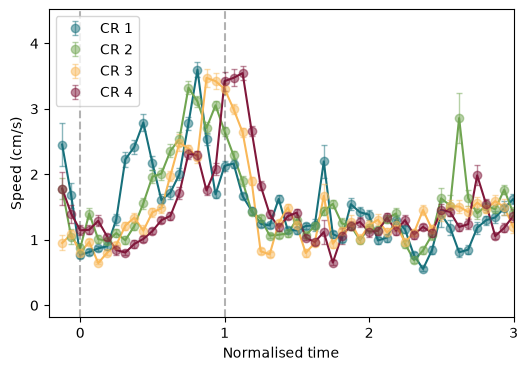

In [54]:
# plotting speed trial averaged
flat_time_array = np.ravel(normalised_time_array.T)
# variable_names = [f"ind_{i}_speed_flattened" for i in range(no_ind)]

no_of_bins = 150
bin_edges = np.linspace(min(flat_time_array), max(flat_time_array), no_of_bins+1)
bin_midpoints = (bin_edges[1:] + bin_edges[:-1])/2
bin_assignments = np.digitize(flat_time_array, bin_edges)

plt.figure(figsize=(6,4))

for i in range(no_ind):
    flat_speed_array = np.ravel(grand_speed[:,:,i])
    bin_means = np.zeros(no_of_bins)
    bin_stderror = np.zeros(no_of_bins)
    for j in range(no_of_bins):
        mask = (bin_assignments == j)
        speeds_in_bin = flat_speed_array[mask]
        if len(speeds_in_bin) > 0:
            if np.all(np.isnan(speeds_in_bin)):
                bin_means[j] = np.nan
                bin_stderror[j] = np.nan
            else:
                bin_means[j] = np.nanmean(speeds_in_bin)
                valid_N = np.sum(~np.isnan(speeds_in_bin))
                bin_stderror[j] = np.nanstd(speeds_in_bin, ddof=1)/np.sqrt(valid_N)
        else:
            bin_means[j] = np.nan
            bin_stderror[j] = np.nan
    plt.plot(bin_midpoints, bin_means, color=colors_ind[i])
    plt.errorbar(bin_midpoints, bin_means, bin_stderror, fmt='o', elinewidth=1, capsize=2, alpha=0.5, label=f"CR {i+1}", color=colors_ind[i])
plt.xticks([0,1,2,3])
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.3)
plt.xlabel("Normalised time")
plt.ylabel("Speed (cm/s)")
plt.xlim(min(flat_time_array), 3)
plt.legend()

In [55]:
# polarization
vel_norm_x = grand_velocity_array[:,:,:,0]/grand_speed
vel_norm_y = grand_velocity_array[:,:,:,1]/grand_speed

grand_mx = np.absolute(np.nanmean(vel_norm_x, axis=2))
grand_my = np.absolute(np.nanmean(vel_norm_y, axis=2))
grand_m = np.sqrt(grand_mx**2 + grand_my**2)


/tmp/ipykernel_5020/3526704219.py:2: RuntimeWarning: invalid value encountered in divide
  vel_norm_x = grand_velocity_array[:,:,:,0]/grand_speed
/tmp/ipykernel_5020/3526704219.py:3: RuntimeWarning: invalid value encountered in divide
  vel_norm_y = grand_velocity_array[:,:,:,1]/grand_speed
/tmp/ipykernel_5020/3526704219.py:5: RuntimeWarning: Mean of empty slice
  grand_mx = np.absolute(np.nanmean(vel_norm_x, axis=2))
/tmp/ipykernel_5020/3526704219.py:6: RuntimeWarning: Mean of empty slice
  grand_my = np.absolute(np.nanmean(vel_norm_y, axis=2))


In [56]:
# function to plot accross trial average stuff

def trial_avergage_plotter(no_of_bins, array, label, color):
    # no_of_bins = 150
    bin_edges = np.linspace(min(flat_time_array), max(flat_time_array), no_of_bins+1)
    bin_midpoints = (bin_edges[1:] + bin_edges[:-1])/2
    bin_assignments = np.digitize(flat_time_array, bin_edges)

    flat_array = np.ravel(array)
    bin_means = np.zeros(no_of_bins)
    bin_stderror = np.zeros(no_of_bins)
    for j in range(no_of_bins):
        mask = (bin_assignments == j)
        speeds_in_bin = flat_array[mask]
        if len(speeds_in_bin) > 0:
            if np.all(np.isnan(speeds_in_bin)):
                bin_means[j] = np.nan
                bin_stderror[j] = np.nan
            else:
                bin_means[j] = np.nanmean(speeds_in_bin)
                valid_N = np.sum(~np.isnan(speeds_in_bin))
                bin_stderror[j] = np.nanstd(speeds_in_bin, ddof=1)/np.sqrt(valid_N)
        else:
            bin_means[j] = np.nan
            bin_stderror[j] = np.nan
    plt.plot(bin_midpoints, bin_means, color=color)
    plt.errorbar(bin_midpoints, bin_means, bin_stderror, fmt='o', elinewidth=1, capsize=2, alpha=0.5, label=label, color=color)


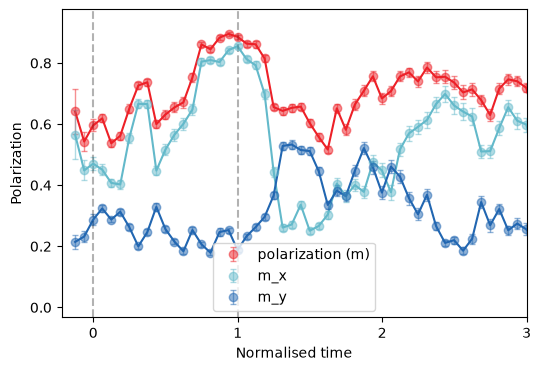

In [57]:
# plotting polarization

plt.figure(figsize=(6,4))

trial_avergage_plotter(150, grand_m, "polarization (m)", colors_MD[0])
trial_avergage_plotter(150, grand_mx, "m_x", colors_MD[1])
trial_avergage_plotter(150, grand_my, "m_y", colors_MD[2])

plt.xticks([0,1,2,3])
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.3)
plt.xlabel("Normalised time")
plt.ylabel("Polarization")
plt.xlim(min(flat_time_array), 3)
plt.legend()


In [58]:
# Dispersion
grand_gc_x = np.mean(grand_trajectories_array[:,:,:,0], axis=2)
grand_gc_y = np.mean(grand_trajectories_array[:,:,:,1], axis=2)
print(grand_gc_x.shape)
grand_rel_gc_pos = np.zeros(grand_trajectories_array.shape)

grand_rel_gc_pos[:,:,:,0] = grand_trajectories_array[:,:,:,0] - grand_gc_x[:,:,None]
grand_rel_gc_pos[:,:,:,1] = grand_trajectories_array[:,:,:,1] - grand_gc_y[:,:,None]

grand_dist_gc = np.linalg.norm(grand_rel_gc_pos, axis=3, ord=2)

# Dispersion
D = np.squeeze(np.mean(grand_dist_gc, axis=2))

# Dispersion along x
D_x = np.mean(np.abs(np.squeeze(grand_rel_gc_pos[:,:,:,0])), axis=2)

# Dispersion along y
D_y = np.mean(np.abs(np.squeeze(grand_rel_gc_pos[:,:,:,1])), axis=2)


(9, 1884)


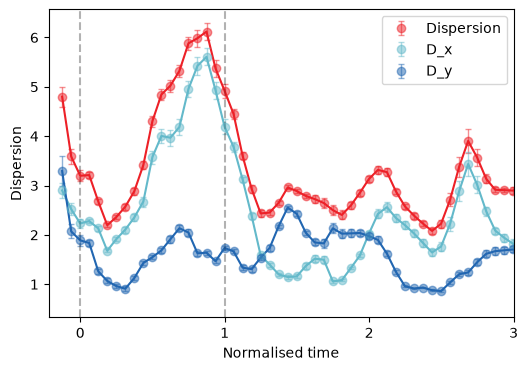

In [59]:
# Plotting dispersion

plt.figure(figsize=(6,4))

trial_avergage_plotter(150, D, "Dispersion", colors_MD[0])
trial_avergage_plotter(150, D_x, "D_x", colors_MD[1])
trial_avergage_plotter(150, D_y, "D_y", colors_MD[2])

plt.xticks([0,1,2,3])
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.3)
plt.xlabel("Normalised time")
plt.ylabel("Dispersion")
plt.xlim(min(flat_time_array), 3)
plt.legend()

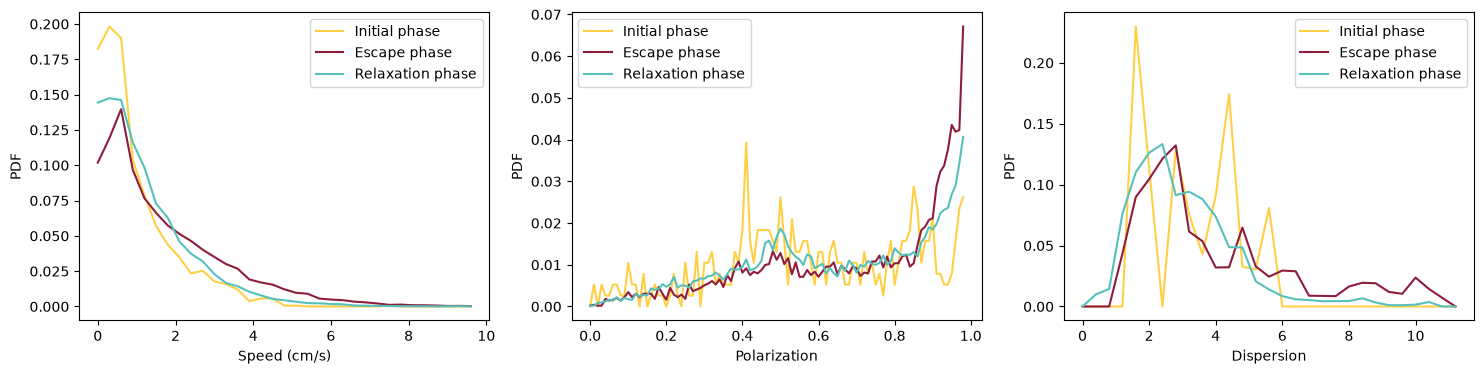

In [60]:
# PDF's in three different phases: Initial, Escape and Relaxation
initial_phase_mask = (flat_time_array < 0)
escape_phase_mask = (flat_time_array >= 0) & (flat_time_array < 1)
relaxation_phase_mask = (flat_time_array >= 1 )

# speed 
speed_bins = np.arange(0, 10, 0.3)

grand_speed_reshaped = grand_speed.reshape(-1, 4)

initial_speed = grand_speed_reshaped[initial_phase_mask].ravel()
escape_speed = grand_speed_reshaped[escape_phase_mask].ravel()
relaxation_speed = grand_speed_reshaped[relaxation_phase_mask].ravel()

i_speed_counts, i_speed_edges = np.histogram(initial_speed, bins=speed_bins)
i_speed_p = i_speed_counts/i_speed_counts.sum()
e_speed_counts, e_speed_edges = np.histogram(escape_speed, bins=speed_bins)
e_speed_p = e_speed_counts/e_speed_counts.sum()
r_speed_counts, r_speed_edges = np.histogram(relaxation_speed, bins=speed_bins)
r_speed_p = r_speed_counts/r_speed_counts.sum()

# Polarization
m_bins = np.arange(0, 1, 0.01)

flat_grand_m = np.ravel(grand_m)

initial_m = flat_grand_m[initial_phase_mask]
escape_m = flat_grand_m[escape_phase_mask]
relaxation_m = flat_grand_m[relaxation_phase_mask]

i_m_counts, i_m_edges = np.histogram(initial_m, bins=m_bins)
i_m_p = i_m_counts/i_m_counts.sum()
e_m_counts, e_m_edges = np.histogram(escape_m, bins=m_bins)
e_m_p = e_m_counts/e_m_counts.sum()
r_m_counts, r_m_edges = np.histogram(relaxation_m, bins=m_bins)
r_m_p = r_m_counts/r_m_counts.sum()

# Dispersion
D_bins = np.arange(0, 12, 0.4)

flat_D = np.ravel(D)

initial_D = flat_D[initial_phase_mask]
escape_D = flat_D[escape_phase_mask]
relaxation_D = flat_D[relaxation_phase_mask]

i_D_counts, i_D_edges = np.histogram(initial_D, bins=D_bins)
i_D_p = i_D_counts/i_D_counts.sum()
e_D_counts, e_D_edges = np.histogram(escape_D, bins=D_bins)
e_D_p = e_D_counts/e_D_counts.sum()
r_D_counts, r_D_edges = np.histogram(relaxation_D, bins=D_bins)
r_D_p = r_D_counts/r_D_counts.sum()

# Plotting
fig,ax = plt.subplots(1, 3, figsize=(18,4))

labels = ["Initial phase", "Escape phase", "Relaxation phase"]
bins = [speed_bins, m_bins, D_bins]
speed_pdfs = [i_speed_p, e_speed_p, r_speed_p]
m_pdfs = [i_m_p, e_m_p, r_m_p]
D_pdfs = [i_D_p, e_D_p, r_D_p]

for i in range(len(labels)):
    ax[0].plot(bins[0][:-1], speed_pdfs[i], label=labels[i], color=colors_phase[i])
    ax[0].set_xlabel("Speed (cm/s)")
    ax[0].set_ylabel("PDF")
    ax[0].legend()

for i in range(len(labels)):
    ax[1].plot(bins[1][:-1], m_pdfs[i], label=labels[i], color=colors_phase[i])
    ax[1].set_xlabel("Polarization")
    ax[1].set_ylabel("PDF")
    ax[1].legend()

for i in range(len(labels)):
    ax[2].plot(bins[2][:-1], D_pdfs[i], label=labels[i], color=colors_phase[i])
    ax[2].set_xlabel("Dispersion")
    ax[2].set_ylabel("PDF")
    ax[2].legend()


In [61]:
crossing_rank_array.shape

(4, 9)

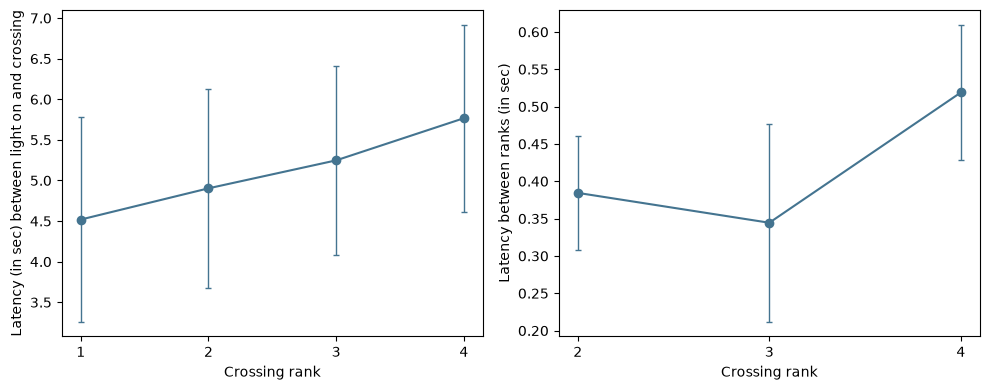

In [62]:
# time since green light on v/s CR and time since previous fish crossed v/s CR

light_on_frame_list = np.array([64,36,60,40,44,24,40,36,52])
frame_rate = 100

CR_crossing_time_array = np.zeros(crossing_rank_array.shape)
for i in range(no_ind):
    for j in range(no_of_trials):
        CR_crossing_time_array[i,j] = crossing_rank_array[i,j][1]

t_since_light_on = (CR_crossing_time_array - light_on_frame_list[None,:])/frame_rate

mean_t_diff = np.mean(t_since_light_on, axis=1)
std_error_t_diff = np.std(t_since_light_on, axis=1, ddof=1)/np.sqrt(no_of_trials)

CR_ids = np.arange(1,no_ind+1,1)

# latency between crossing
between_rank_latency = (CR_crossing_time_array[1:,:] - CR_crossing_time_array[:-1,:])/100

mean_brl = np.mean(between_rank_latency, axis=1)
std_error_brl = np.std(between_rank_latency, axis=1, ddof=1)/np.sqrt(no_of_trials)

# plotting
fig,ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(CR_ids, mean_t_diff, color="#447490")
ax[0].errorbar(CR_ids, mean_t_diff, std_error_t_diff, fmt='o', elinewidth=1, capsize=2, color="#447490")
ax[0].set_xticks(CR_ids)
ax[0].set_xlabel("Crossing rank")
ax[0].set_ylabel("Latency (in sec) between light on and crossing")

ax[1].plot(CR_ids[1:], mean_brl, color="#447490")
ax[1].errorbar(CR_ids[1:], mean_brl, std_error_brl, fmt='o', elinewidth=1, capsize=2, color="#447490")
ax[1].set_xticks(CR_ids[1:])
ax[1].set_xlabel("Crossing rank")
ax[1].set_ylabel("Latency between ranks (in sec)")

fig.tight_layout()

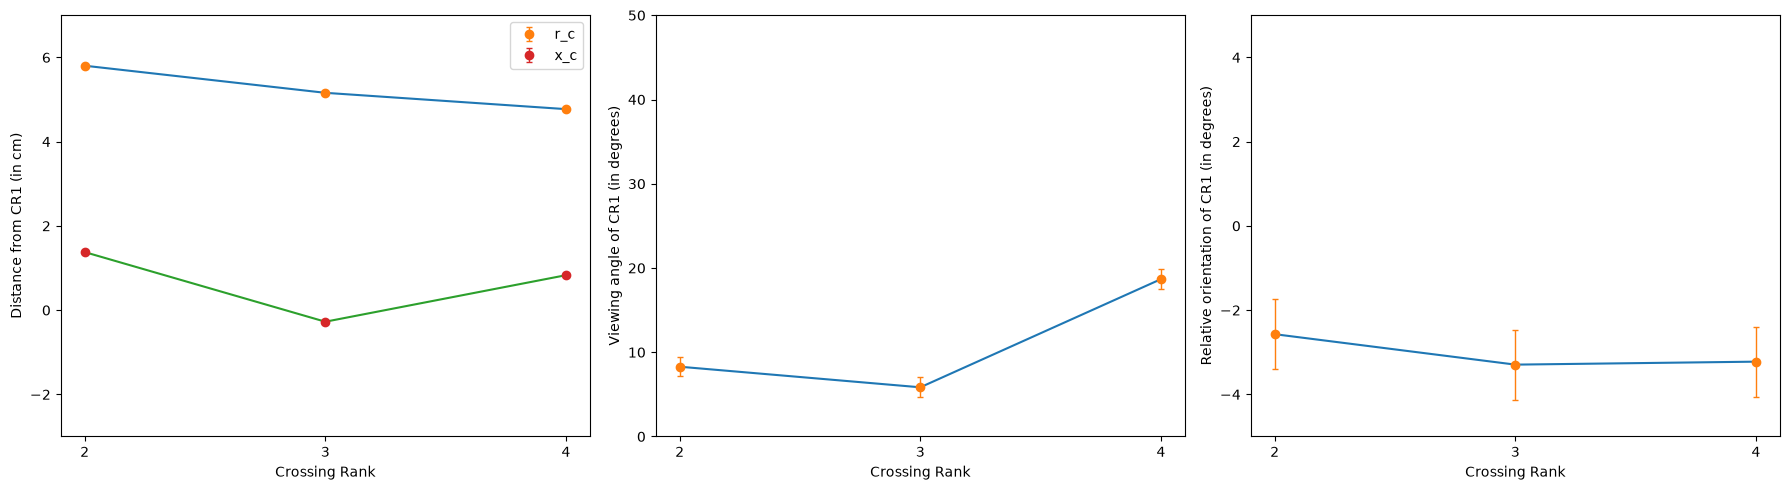

In [67]:
# distance, viewing angle and relative orientation vs CR

# distance between CR1
between_CR1 = grand_trajectories_array[:,:,1:,:] - grand_trajectories_array[:,:,:-1,:]
dist_between_CR1 = np.linalg.norm(between_CR1, axis=3, ord=2)
x_dist_between_CR1 = between_CR1[:,:,:,0]
flat_dist = dist_between_CR1.reshape(-1,dist_between_CR1.shape[2])
flat_dist_x = x_dist_between_CR1.reshape(-1, x_dist_between_CR1.shape[2])

mean_dist = np.nanmean(flat_dist, axis=0)
std_error_dist = np.nanstd(flat_dist, axis=0, ddof=1)/np.sqrt(flat_dist.shape[0])

mean_dist_x = np.nanmean(flat_dist_x, axis=0)
std_error_dist_x = np.nanstd(flat_dist_x, axis=0, ddof=1)/np.sqrt(flat_dist_x.shape[0])

# Viewing angle of CR1
CR1_pos = np.squeeze(grand_trajectories_array[:,:,0,:])
rel_pos_wrt_CR1 = grand_trajectories_array - CR1_pos[:,:,None,:]

rel_angle_from_x = np.arctan2(rel_pos_wrt_CR1[:,:,:,1], rel_pos_wrt_CR1[:,:,:,0])
viewing_angle = (grand_heading - rel_angle_from_x[:,:-1,:])*(180/np.pi)
flat_viewing_angle = viewing_angle[:,:,1:].reshape(-1,viewing_angle.shape[2]-1)
mean_va = np.nanmean(flat_viewing_angle, axis=0)
std_error_va = np.nanstd(flat_viewing_angle, axis=0, ddof=1)/np.sqrt(flat_viewing_angle.shape[0])

# Relative orientation
CR1_heading = np.squeeze(grand_heading[:,:,0])
rel_orientation = grand_heading - CR1_heading[:,:,None]*(180/np.pi)
flat_rel_orientation = rel_orientation[:,:,1:].reshape(-1, rel_orientation.shape[2]-1)
mean_ro = np.nanmean(flat_rel_orientation, axis=0)
std_error_ro = np.nanstd(flat_rel_orientation, axis=0, ddof=1)/np.sqrt(flat_viewing_angle.shape[0])

# plotting
fig, ax = plt.subplots(1, 3, figsize=(18,5))

ax[0].plot(CR_ids[1:], mean_dist)
ax[0].errorbar(CR_ids[1:], mean_dist, std_error_dist, fmt='o', elinewidth=1, capsize=2, label="r_c")
ax[0].plot(CR_ids[1:], mean_dist_x)
ax[0].errorbar(CR_ids[1:], mean_dist_x, std_error_dist_x, fmt='o', elinewidth=1, capsize=2, label="x_c")
ax[0].set_xticks(CR_ids[1:])
ax[0].set_xlabel("Crossing Rank")
ax[0].set_ylabel("Distance from CR1 (in cm)")
ax[0].set_ylim(-3, 7)
ax[0].legend()

ax[1].plot(CR_ids[1:], mean_va)
ax[1].errorbar(CR_ids[1:], mean_va, std_error_va, fmt='o', elinewidth=1, capsize=2)
ax[1].set_xticks(CR_ids[1:])
ax[1].set_xlabel("Crossing Rank")
ax[1].set_ylabel("Viewing angle of CR1 (in degrees)")
ax[1].set_ylim(0, 50)

ax[2].plot(CR_ids[1:], mean_ro)
ax[2].errorbar(CR_ids[1:], mean_ro, std_error_ro, fmt='o', elinewidth=1, capsize=2)
ax[2].set_xticks(CR_ids[1:])
ax[2].set_xlabel("Crossing Rank")
ax[2].set_ylabel("Relative orientation of CR1 (in degrees)")
ax[2].set_ylim(-5, 5)

fig.tight_layout()

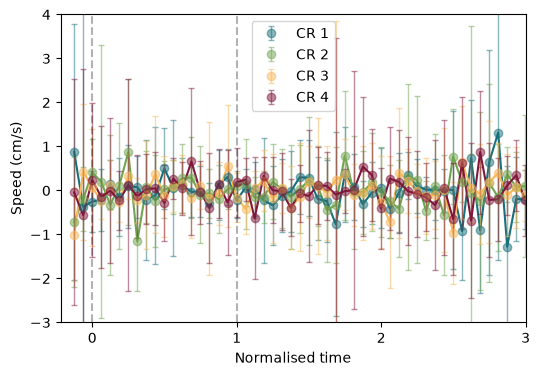

In [65]:
# plotting acceleration 
flat_time_array = np.ravel(normalised_time_array.T)
# variable_names = [f"ind_{i}_speed_flattened" for i in range(no_ind)]

no_of_bins = 150
bin_edges = np.linspace(min(flat_time_array), max(flat_time_array), no_of_bins+1)
bin_midpoints = (bin_edges[1:] + bin_edges[:-1])/2
bin_assignments = np.digitize(flat_time_array, bin_edges)

plt.figure(figsize=(6,4))

for i in range(no_ind):
    flat_acc_array = np.ravel(np.squeeze(grand_acceleration_array[:,:,i,1]))
    bin_means = np.zeros(no_of_bins)
    bin_stderror = np.zeros(no_of_bins)
    for j in range(no_of_bins):
        mask = (bin_assignments == j)
        acc_in_bin = flat_acc_array[mask]
        if len(acc_in_bin) > 0:
            if np.all(np.isnan(acc_in_bin)):
                bin_means[j] = np.nan
                bin_stderror[j] = np.nan
            else:
                bin_means[j] = np.nanmean(acc_in_bin)
                valid_N = np.sum(~np.isnan(acc_in_bin))
                bin_stderror[j] = np.nanstd(acc_in_bin, ddof=1)/np.sqrt(valid_N)
        else:
            bin_means[j] = np.nan
            bin_stderror[j] = np.nan
    plt.plot(bin_midpoints, bin_means, color=colors_ind[i])
    plt.errorbar(bin_midpoints, bin_means, bin_stderror, fmt='o', elinewidth=1, capsize=2, alpha=0.5, label=f"CR {i+1}", color=colors_ind[i])
plt.xticks([0,1,2,3])
plt.axvline(x=0, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.3)
plt.xlabel("Normalised time")
plt.ylabel("Speed (cm/s)")
plt.xlim(min(flat_time_array), 3)
plt.ylim(-3, 4)
plt.legend()

In [86]:
# strength of pattern

def significance_of_pattern(CR, array, p_threshold):
    rho, p_value = stats.spearmanr(CR, array)
    if p_value > p_threshold:
        print(f"Failed to reject the null hypothesis: No significant pattern exists for")
    else:
        print("Rejected the null hypothesis: A significant pattern exists.")
    return rho, p_value

significance_of_pattern(CR_ids[1:], mean_brl, 0.05)

Failed to reject the null hypothesis: No significant pattern exists for


(np.float64(0.5), np.float64(0.6666666666666666))